<a href="https://colab.research.google.com/github/AndrejHorvat1/Multibeam-Forward-Looking-Sonar/blob/main/UATD_BILAT_HISTEQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
from glob import glob
import shutil

base_input = "/content/drive/MyDrive/UATD_YOLO_Dataset_v2"
base_output = "/content/drive/MyDrive/UATD_YOLO_Dataset_BILAT_HISTEQ"

# Bilateralni filter parametri
d = 9
sigmaColor = 75
sigmaSpace = 75

def preprocess_and_save(image_dir, label_dir, output_dir, subset):
    img_input = os.path.join(image_dir, subset)
    lbl_input = os.path.join(label_dir, subset)
    img_output = os.path.join(output_dir, "images", subset)
    lbl_output = os.path.join(output_dir, "labels", subset)

    os.makedirs(img_output, exist_ok=True)
    os.makedirs(lbl_output, exist_ok=True)

    image_paths = sorted(glob(os.path.join(img_input, "*.jpg")))

    for img_path in image_paths:
        img_name = os.path.basename(img_path)
        label_name = img_name.replace(".jpg", ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        # Pretvori u YCrCb radi boljeg rada s kontrastom
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        y, cr, cb = cv2.split(ycrcb)

        # Bilateralni filter na Y kanal
        y_filtered = cv2.bilateralFilter(y, d=d, sigmaColor=sigmaColor, sigmaSpace=sigmaSpace)

        # Ekvalizacija histograma na filtriranom Y kanalu
        y_eq = cv2.equalizeHist(y_filtered)

        # Spajanje kanala nazad
        ycrcb_eq = cv2.merge((y_eq, cr, cb))
        final_img = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2BGR)

        cv2.imwrite(os.path.join(img_output, img_name), final_img)

        src_label = os.path.join(lbl_input, label_name)
        dst_label = os.path.join(lbl_output, label_name)

        if os.path.exists(src_label):
            shutil.copyfile(src_label, dst_label)

        print(f"{subset}/{img_name} spremljeno.")



preprocess_and_save(
    image_dir=os.path.join(base_input, "images"),
    label_dir=os.path.join(base_input, "labels"),
    output_dir=base_output,
    subset="train"
)

preprocess_and_save(
    image_dir=os.path.join(base_input, "images"),
    label_dir=os.path.join(base_input, "labels"),
    output_dir=base_output,
    subset="val"
)


Izlaz streaminga skraćen je na ovoliko posljednjih redaka: 5000.
train/06385.jpg spremljeno.
train/06385_aug.jpg spremljeno.
train/06387.jpg spremljeno.
train/06387_aug.jpg spremljeno.
train/06389.jpg spremljeno.
train/06389_aug.jpg spremljeno.
train/06390.jpg spremljeno.
train/06390_aug.jpg spremljeno.
train/06391.jpg spremljeno.
train/06391_aug.jpg spremljeno.
train/06392.jpg spremljeno.
train/06392_aug.jpg spremljeno.
train/06393.jpg spremljeno.
train/06393_aug.jpg spremljeno.
train/06395.jpg spremljeno.
train/06395_aug.jpg spremljeno.
train/06397.jpg spremljeno.
train/06397_aug.jpg spremljeno.
train/06398.jpg spremljeno.
train/06398_aug.jpg spremljeno.
train/06399.jpg spremljeno.
train/06399_aug.jpg spremljeno.
train/06400.jpg spremljeno.
train/06400_aug.jpg spremljeno.
train/06402.jpg spremljeno.
train/06402_aug.jpg spremljeno.
train/06403.jpg spremljeno.
train/06403_aug.jpg spremljeno.
train/06404.jpg spremljeno.
train/06404_aug.jpg spremljeno.
train/06405.jpg spremljeno.
train/0

In [ ]:
import os
import cv2
import shutil
from glob import glob

test_sets = ["test_set1", "test_set2"]

original_base = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_v2"
output_base   = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_BILAT_HISTEQ"

# Parametri za bilateralni filter
d = 9
sigmaColor = 75
sigmaSpace = 75

for set_name in test_sets:
    inp_img_dir  = os.path.join(original_base, "images", set_name)
    inp_lbl_dir  = os.path.join(original_base, "labels", set_name)
    out_img_dir  = os.path.join(output_base,   "images", set_name)
    out_lbl_dir  = os.path.join(output_base,   "labels", set_name)

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    for img_path in sorted(glob(os.path.join(inp_img_dir, "*.jpg"))):
        img_name   = os.path.basename(img_path)
        img_id     = os.path.splitext(img_name)[0]
        lbl_src    = os.path.join(inp_lbl_dir, img_id + ".txt")
        lbl_dest   = os.path.join(out_lbl_dir, img_id + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            print(f"Ne mogu učitati {img_path}, preskačem…")
            continue

        # Konverzija u YCrCb prostor
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        y, cr, cb = cv2.split(ycrcb)

        # Bilateralni filter na Y-kanalu
        y_filtered = cv2.bilateralFilter(y, d, sigmaColor, sigmaSpace)

        # Glob. ekvalizacija histograma na filtriranom Y-kanalu
        y_eq = cv2.equalizeHist(y_filtered)

        # Spoji kanale i vrati u BGR
        ycrcb_eq  = cv2.merge((y_eq, cr, cb))
        final_img = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2BGR)

        cv2.imwrite(os.path.join(out_img_dir, img_name), final_img)

        if os.path.exists(lbl_src):
            shutil.copyfile(lbl_src, lbl_dest)

        print(f"{set_name}/{img_name} obrađeno i spremljeno.")

print("\nBF+EH spremljeni u:", output_base)


test_set1/00001.jpg obrađeno i spremljeno.
test_set1/00002.jpg obrađeno i spremljeno.
test_set1/00003.jpg obrađeno i spremljeno.
test_set1/00004.jpg obrađeno i spremljeno.
test_set1/00005.jpg obrađeno i spremljeno.
test_set1/00006.jpg obrađeno i spremljeno.
test_set1/00007.jpg obrađeno i spremljeno.
test_set1/00008.jpg obrađeno i spremljeno.
test_set1/00009.jpg obrađeno i spremljeno.
test_set1/00010.jpg obrađeno i spremljeno.
test_set1/00011.jpg obrađeno i spremljeno.
test_set1/00012.jpg obrađeno i spremljeno.
test_set1/00013.jpg obrađeno i spremljeno.
test_set1/00014.jpg obrađeno i spremljeno.
test_set1/00015.jpg obrađeno i spremljeno.
test_set1/00016.jpg obrađeno i spremljeno.
test_set1/00017.jpg obrađeno i spremljeno.
test_set1/00018.jpg obrađeno i spremljeno.
test_set1/00019.jpg obrađeno i spremljeno.
test_set1/00020.jpg obrađeno i spremljeno.
test_set1/00021.jpg obrađeno i spremljeno.
test_set1/00022.jpg obrađeno i spremljeno.
test_set1/00023.jpg obrađeno i spremljeno.
test_set1/0

In [ ]:
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_BILAT_HISTEQ" /content/
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_Test_BILAT_HISTEQ" /content/

In [ ]:
#yolov5 konfiguracija
data_yaml = """train: /content/UATD_YOLO_Dataset_BILAT_HISTEQ/images/train
val: /content/UATD_YOLO_Dataset_BILAT_HISTEQ/images/val
nc: 10
test:
  - /content/UATD_YOLO_Dataset_Test_BILAT_HISTEQ/images/test_set1
  - /content/UATD_YOLO_Dataset_Test_BILAT_HISTEQ/images/test_set2
names: ['cube', 'ball', 'cylinder', 'human body', 'plane', 'circle cage', 'square cage', 'metal bucket', 'tyre', 'rov']
"""

os.makedirs("yolo_dataset", exist_ok=True)

with open("yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)


In [ ]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 21.5M/21.5M [00:00<00:00, 202MB/s]



 Epoha 1/15
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_loop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 21.4MB/s]

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

...

                   all       3038       4954      0.889      0.848      0.878       0.45

1 epochs completed in 0.111 hours.
Optimizer stripped from runs/custom_loop/weights/last.pt, 22.5MB
Optimizer stripped from runs/custom_loop/weights/best.pt, 22.5MB

Validating runs/custom_loop/weights/best.pt...
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [00:42<00:00,  4.47it/s]


                   all       3038       4954       0.89      0.848      0.878       0.45
                  cube       1050       1052       0.96      0.911      0.948      0.512
                  ball       1210       1212      0.938      0.894      0.922      0.496
              cylinder        226        226       0.84      0.765      0.833       0.39
            human body        556        558      0.898      0.868      0.891      0.444
                 plane        334        334      0.969      0.933      0.967      0.609
           circle cage        282        284      0.848      0.843      0.828      0.433
           square cage        376        376      0.949      0.841      0.924      0.461
          metal bucket        194        194      0.914      0.948       0.96      0.474
                  tyre        454        458      0.874      0.832      0.864      0.461
                   rov        260        260      0.707      0.642      0.642      0.217
Speed: 0.2ms preproce

val: Scanning /content/UATD_YOLO_Dataset_Test_BILAT_HISTEQ/labels/test_set1.cache... 1596 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1596/1596 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 200/200 [00:28<00:00,  7.11it/s]


                   all       1596       2323      0.779      0.749      0.742      0.303
                  cube        338        338      0.657      0.873      0.628      0.223
                  ball        390        390      0.882      0.859      0.855      0.439
              cylinder         93         93      0.878      0.852      0.897      0.322
            human body        149        149      0.731       0.84      0.802      0.303
                 plane        269        269      0.953      0.982      0.987      0.591
           circle cage        197        197      0.616      0.431      0.463      0.195
           square cage        335        335      0.799      0.545       0.58      0.186
          metal bucket         11         11      0.732      0.818      0.849      0.255
                  tyre        241        241      0.803      0.718      0.756       0.33
                   rov        300        300      0.741      0.571      0.603      0.184
Speed: 0.3ms preproce

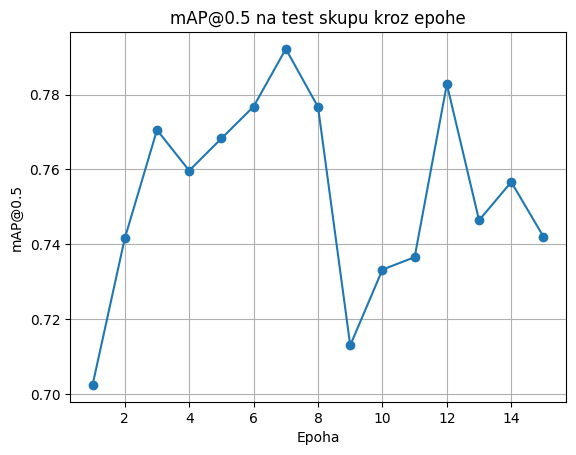

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os

# Konfiguracija
DATA_YAML_PATH = "yolo_dataset/data.yaml"
BEST_MODEL_PATH = "best_yolov8.pt"
INITIAL_WEIGHTS = "yolov8s.pt"
EPOCHS = 15

# Inicijaliziraj model
model = YOLO(INITIAL_WEIGHTS)
map_scores = []
best_map = 0.0

# Loop po epohama
for epoch in range(EPOCHS):
    print(f"\n Epoha {epoch + 1}/{EPOCHS}")

    # Treniraj samo 1 epohu
    model.train(data=DATA_YAML_PATH, epochs=1, batch=8, imgsz=640, project="runs", name="custom_loop", verbose=True, exist_ok=True)

    # Validacija na test skupu
    metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=640, batch=8)

    # Dohvati mAP@0.5 i dodaj u listu
    map_50 = metrics.box.map50  # float
    print(f"mAP@0.5 test: {map_50:.4f}")
    map_scores.append(map_50)


# Plotanje rezultata
plt.plot(range(1, EPOCHS + 1), map_scores, marker='o')
plt.title("mAP@0.5 na test skupu kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("mAP@0.5")
plt.grid(True)
plt.show()


!cp -r runs/custom_loop /content/drive/MyDrive/yolov8_BILAT_HISTEQ/